In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Set up plotting style
plt.style.use('ggplot')

DATA_ROOT = '../Data'
SUBJECT = 'AP01'
SUBJECT_PATH = os.path.join(DATA_ROOT, SUBJECT)

def parse_signal_file(filepath, value_col_name='Value'):
    """Parses a signal file (Flow, Thorac, SPO2) into a DataFrame."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Extract metadata if needed (Start Time, Sample Rate)
    # The actual data starts after the header. Let's find the line with "Data:"
    data_start_idx = 0
    for i, line in enumerate(lines):
        if line.strip() == "Data:":
            data_start_idx = i + 1
            break
            
    data_lines = lines[data_start_idx:]
    
    timestamps = []
    values = []
    
    for line in data_lines:
        if ';' in line:
            parts = line.strip().split(';')
            ts_str = parts[0].strip()
            val_str = parts[1].strip()
            
            # Timestamp format: 30.05.2024 20:59:00,000
            # Replace ',' with '.' for standard parsing if needed, or parse manually
            ts_str = ts_str.replace(',', '.')
            timestamps.append(ts_str)
            values.append(float(val_str))
            
    df = pd.DataFrame({
        'Timestamp': pd.to_datetime(timestamps, format='%d.%m.%Y %H:%M:%S.%f'),
        value_col_name: values
    })
    return df

def parse_event_file(filepath):
    """Parses the Flow Events file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    data_lines = [l for l in lines if ';' in l and l[0].isdigit()]
    
    events = []
    for line in data_lines:
        # 30.05.2024 23:48:45,119-23:49:01,408; 16;Hypopnea; N1
        parts = line.strip().split(';')
        time_range = parts[0].strip()
        duration = parts[1].strip()
        event_type = parts[2].strip()
        stage = parts[3].strip() if len(parts) > 3 else None
        
        # Split time range
        if '-' in time_range:
            start_str, end_time_str = time_range.split('-')
            
            # Parse start
            start_ts = pd.to_datetime(start_str.replace(',', '.'), format='%d.%m.%Y %H:%M:%S.%f')
            
            # End time string might not have date, or might. 
            # In the file sample: 23:49:01,408 (no date). 
            # We need to handling date rollover if end time < start time (time-wise)
            # But wait, looking at the sample: 
            # Start: 30.05.2024 23:48:45,119
            # End of range text: 23:49:01,408
            # So we combine the start date with end time.
            
            end_ts_str = f"{start_ts.strftime('%d.%m.%Y')} {end_time_str}".replace(',', '.')
            try:
                end_ts = pd.to_datetime(end_ts_str, format='%d.%m.%Y %H:%M:%S.%f')
            except ValueError:
                # Handle cases where date rolls over but isn't in string? 
                # If end_time_str is just time, and it's smaller than start time, add a day.
                # But let's check format first.
                pass
                
            # Check for day rollover in minimal way: 
            if end_ts < start_ts:
                end_ts = end_ts + pd.Timedelta(days=1)
                
            events.append({
                'Start': start_ts,
                'End': end_ts,
                'Duration': duration,
                'Type': event_type,
                'Stage': stage
            })
            
    return pd.DataFrame(events)

def parse_sleep_profile(filepath):
    """Parses the Sleep Profile file."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    data_lines = [l for l in lines if ';' in l and l[0].isdigit()]
    
    profile = []
    for line in data_lines:
        parts = line.strip().split(';')
        ts_str = parts[0].strip().replace(',', '.')
        stage = parts[1].strip()
        
        profile.append({
            'Timestamp': pd.to_datetime(ts_str, format='%d.%m.%Y %H:%M:%S.%f'),
            'Stage': stage
        })
        
    return pd.DataFrame(profile)

In [2]:
def get_subject_files(subject_id, data_root='../Data'):
    """Finds the file paths for a given subject."""
    subject_dir = os.path.join(data_root, subject_id)
    files = os.listdir(subject_dir)
    
    file_map = {}
    for f in files:
        lower_f = f.lower()
        if 'events' in lower_f:
            file_map['Events'] = os.path.join(subject_dir, f)
        elif 'profile' in lower_f:
            file_map['Profile'] = os.path.join(subject_dir, f)
        elif 'spo2' in lower_f:
            file_map['SPO2'] = os.path.join(subject_dir, f)
        elif 'thorac' in lower_f:
            file_map['Thorac'] = os.path.join(subject_dir, f)
        elif 'flow' in lower_f:
            file_map['Flow'] = os.path.join(subject_dir, f)
            
    return file_map

def parse_signal(filepath, signal_name):
    """
    Parses a single signal file (Flow, Thorac, SPO2).
    Format:
    Header...
    Data:
    dd.mm.yyyy HH:MM:SS,fff; value
    """
    # Read all lines
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    # Find start of data
    start_idx = 0
    for i, line in enumerate(lines):
        if line.strip() == "Data:":
            start_idx = i + 1
            break
            
    # Process data lines
    data = []
    for line in lines[start_idx:]:
        if ';' not in line:
            continue
        parts = line.strip().split(';')
        if len(parts) < 2:
            continue
            
        ts_str = parts[0].strip().replace(',', '.')
        val_str = parts[1].strip()
        
        try:
            val = float(val_str)
            data.append((ts_str, val))
        except ValueError:
            continue
            
    # Create DataFrame
    df = pd.DataFrame(data, columns=['Timestamp', signal_name])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d.%m.%Y %H:%M:%S.%f')
    return df

def parse_events(filepath):
    """
    Parses the Flow Events file.
    Format: StartTimestamp-EndTime; Duration; Type; Stage
    Example: 30.05.2024 23:48:45,119-23:49:01,408; 16;Hypopnea; N1
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    events = []
    for line in lines:
        # Skip headers or empty lines. A valid line starts with a date digit?
        if ';' not in line or not line[0].isdigit():
            continue
            
        parts = line.strip().split(';')
        range_str = parts[0].strip()
        event_type = parts[2].strip() if len(parts) > 2 else 'Unknown'
        
        if '-' in range_str:
            start_str, end_time_str = range_str.split('-')
            
            # Parse start
            start_ts = pd.to_datetime(start_str.replace(',', '.'), format='%d.%m.%Y %H:%M:%S.%f')
            
            # Parse end
            # End time string usually doesn't have date.
            # We combine start date with end time.
            # But we must be careful if the event spans midnight (start=23:59, end=00:01).
            
            # Construct a candidate end string using start date
            start_date_str = start_ts.strftime('%d.%m.%Y')
            end_candidate_str = f"{start_date_str} {end_time_str}".replace(',', '.')
            
            try:
                end_ts = pd.to_datetime(end_candidate_str, format='%d.%m.%Y %H:%M:%S.%f')
            except ValueError:
                continue

            # Handle midnight crossover
            if end_ts < start_ts:
                end_ts += pd.Timedelta(days=1)
                
            events.append({
                'Start': start_ts,
                'End': end_ts,
                'Type': event_type
            })
            
    return pd.DataFrame(events)

def parse_profile(filepath):
    """
    Parses Sleep Profile.
    Format: Timestamp; Stage
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    data = []
    for line in lines:
        if ';' not in line or not line[0].isdigit():
            continue
            
        parts = line.strip().split(';')
        ts_str = parts[0].strip().replace(',', '.')
        stage = parts[1].strip()
        
        data.append((ts_str, stage))
        
    df = pd.DataFrame(data, columns=['Timestamp', 'Stage'])
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d.%m.%Y %H:%M:%S.%f')
    return df

# Load AP01
subject_id = 'AP01'
files = get_subject_files(subject_id, r'd:\Desktop\Project_root\Data')

print(f"Loading data for {subject_id}...")
df_flow = parse_signal(files['Flow'], 'Flow')
df_thorac = parse_signal(files['Thorac'], 'Thorac')
df_spo2 = parse_signal(files['SPO2'], 'SPO2')
df_events = parse_events(files['Events'])
df_profile = parse_profile(files['Profile'])

print("Data loaded.")
print("Flow range:", df_flow['Timestamp'].min(), "to", df_flow['Timestamp'].max())
print("Events found:", len(df_events))
df_events.head()

Loading data for AP01...
Data loaded.
Flow range: 2024-05-30 20:59:00 to 2024-05-31 04:34:49.469000
Events found: 161


,Start,End,Type
0,2024-05-30 23:48:45.119,2024-05-30 23:49:01.408,Hypopnea
1,2024-05-30 23:50:16.578,2024-05-30 23:50:33.546,Hypopnea
2,2024-05-30 23:52:13.626,2024-05-30 23:52:27.268,Hypopnea
3,2024-05-30 23:52:51.246,2024-05-30 23:53:02.871,Hypopnea
4,2024-05-30 23:53:36.906,2024-05-30 23:53:49.734,Hypopnea


In [3]:
df_events.head()

,Start,End,Type
0,2024-05-30 23:48:45.119,2024-05-30 23:49:01.408,Hypopnea
1,2024-05-30 23:50:16.578,2024-05-30 23:50:33.546,Hypopnea
2,2024-05-30 23:52:13.626,2024-05-30 23:52:27.268,Hypopnea
3,2024-05-30 23:52:51.246,2024-05-30 23:53:02.871,Hypopnea
4,2024-05-30 23:53:36.906,2024-05-30 23:53:49.734,Hypopnea


Plotting Obstructive Apnea...
36


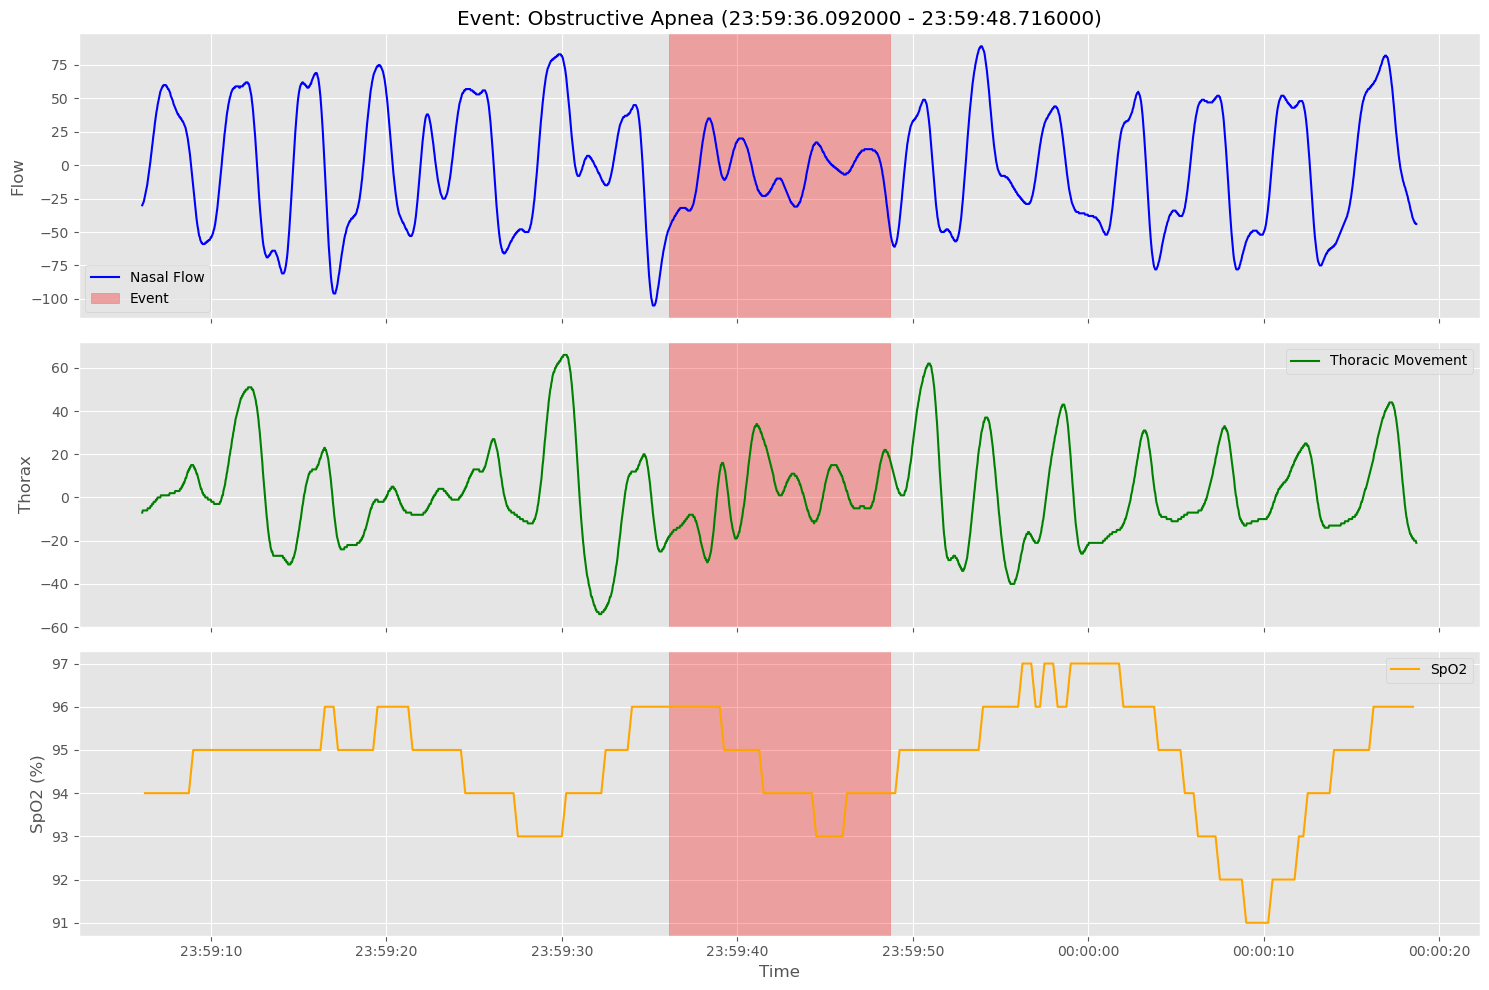

Plotting Hypopnea...
125


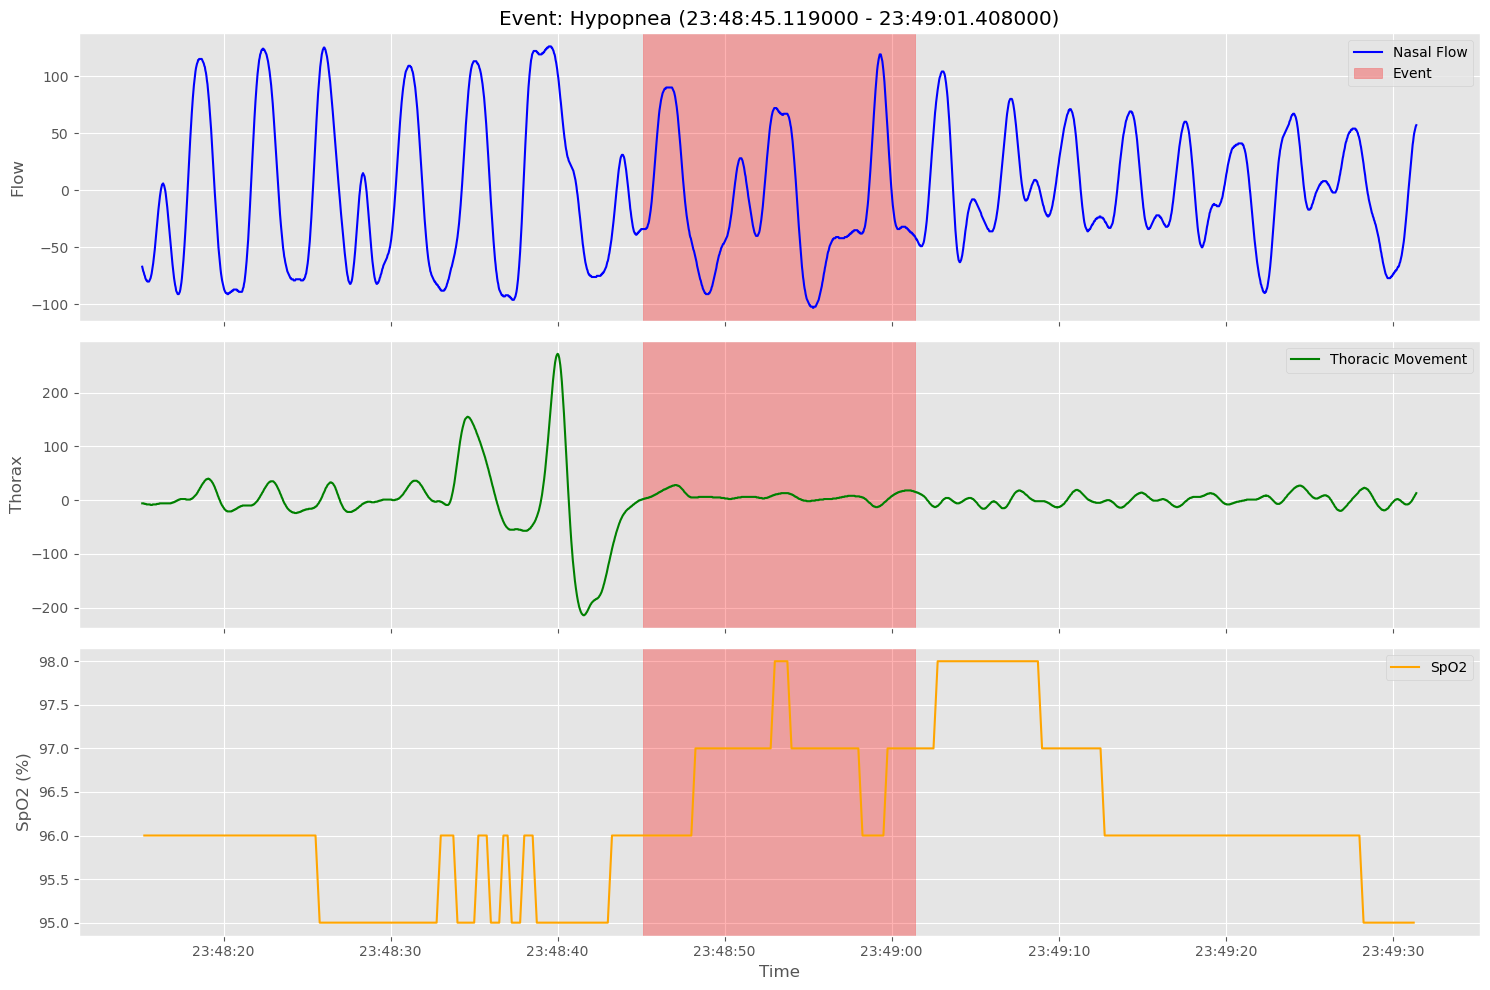

In [4]:
def plot_event(event_index, padding=30):
    event = df_events.iloc[event_index]
    start = event['Start'] - pd.Timedelta(seconds=padding)
    end = event['End'] + pd.Timedelta(seconds=padding)
    
    # Filter signals
    flow_segment = df_flow[(df_flow['Timestamp'] >= start) & (df_flow['Timestamp'] <= end)]
    thorac_segment = df_thorac[(df_thorac['Timestamp'] >= start) & (df_thorac['Timestamp'] <= end)]
    spo2_segment = df_spo2[(df_spo2['Timestamp'] >= start) & (df_spo2['Timestamp'] <= end)]
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    
    axes[0].plot(flow_segment['Timestamp'], flow_segment['Flow'], label='Nasal Flow', color='blue')
    axes[0].set_ylabel('Flow')
    axes[0].set_title(f"Event: {event['Type']} ({event['Start'].time()} - {event['End'].time()})")
    axes[0].axvspan(event['Start'], event['End'], color='red', alpha=0.3, label='Event')
    axes[0].legend()
    
    axes[1].plot(thorac_segment['Timestamp'], thorac_segment['Thorac'], label='Thoracic Movement', color='green')
    axes[1].set_ylabel('Thorax')
    axes[1].axvspan(event['Start'], event['End'], color='red', alpha=0.3)
    axes[1].legend()
    
    axes[2].plot(spo2_segment['Timestamp'], spo2_segment['SPO2'], label='SpO2', color='orange')
    axes[2].set_ylabel('SpO2 (%)')
    axes[2].set_xlabel('Time')
    axes[2].axvspan(event['Start'], event['End'], color='red', alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

# Find first Obstructive Apnea
apnea_indices = df_events[df_events['Type'].str.contains('Apnea')].index
if len(apnea_indices) > 0:
    print("Plotting Obstructive Apnea...")
    print(len(apnea_indices))
    plot_event(apnea_indices[0])
    
# Find first Hypopnea
hypopnea_indices = df_events[df_events['Type'].str.contains('Hypopnea')].index
if len(hypopnea_indices) > 0:
    print("Plotting Hypopnea...")
    print(len(hypopnea_indices))
    plot_event(hypopnea_indices[0])
    # plot_event(hypopnea_indices[0])
    # plot_event(hypopnea_indices[0])

In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

def plot_full_sleep(df_flow, df_thorac, df_spo2, df_events, window_minutes=5, pdf_path="sleep_report.pdf"):
    
    start_time = df_flow['Timestamp'].min()
    end_time = df_flow['Timestamp'].max()
    
    current_time = start_time
    window = pd.Timedelta(minutes=window_minutes)

    with PdfPages(pdf_path) as pdf:

        while current_time < end_time:

            window_end = current_time + window

            # Filter signals
            flow_seg = df_flow[(df_flow['Timestamp'] >= current_time) & (df_flow['Timestamp'] < window_end)]
            thorac_seg = df_thorac[(df_thorac['Timestamp'] >= current_time) & (df_thorac['Timestamp'] < window_end)]
            spo2_seg = df_spo2[(df_spo2['Timestamp'] >= current_time) & (df_spo2['Timestamp'] < window_end)]

            fig, axes = plt.subplots(3,1, figsize=(15,8), sharex=True)

            axes[0].plot(flow_seg['Timestamp'], flow_seg['Flow'], color='blue')
            axes[0].set_ylabel("Flow")
            axes[0].set_title(f"{current_time} to {window_end}")

            axes[1].plot(thorac_seg['Timestamp'], thorac_seg['Thorac'], color='orange')
            axes[1].set_ylabel("Thorax")

            axes[2].plot(spo2_seg['Timestamp'], spo2_seg['SPO2'], color='green')
            axes[2].set_ylabel("SpO2")
            axes[2].set_xlabel("Time")

            # Find events inside window
            events_win = df_events[(df_events['Start'] < window_end) & (df_events['End'] > current_time)]

            for _, event in events_win.iterrows():

                # Choose color based on event type
                if "Hypopnea" in event['Type']:
                    color = "yellow"
                elif "Apnea" in event['Type']:
                    color = "red"
                else:
                    color = "gray"

                # Highlight region
                for ax in axes:
                    ax.axvspan(event['Start'], event['End'], color=color, alpha=0.35)

                # Add label text
                mid_time = event['Start'] + (event['End'] - event['Start']) / 2

                axes[0].text(
                    mid_time,
                    axes[0].get_ylim()[1] * 0.9,
                    event['Type'],
                    ha='center',
                    fontsize=9,
                    color="black",
                    bbox=dict(facecolor=color, alpha=0.5, edgecolor='none')
                )

            plt.tight_layout()

            pdf.savefig(fig)
            plt.close(fig)

            current_time += window

    print(f"Saved: {pdf_path}")

In [6]:
VIS_DIR = "Visualizations"
os.makedirs(VIS_DIR, exist_ok=True)

In [7]:
DATA_ROOT = r'd:\Desktop\Project_root\Data'

subjects = os.listdir(DATA_ROOT)

for subject in subjects:

    try:
        print(f"Processing {subject}")

        files = get_subject_files(subject, DATA_ROOT)

        df_flow = parse_signal(files['Flow'], 'Flow')
        df_thorac = parse_signal(files['Thorac'], 'Thorac')
        df_spo2 = parse_signal(files['SPO2'], 'SPO2')
        df_events = parse_events(files['Events'])

        pdf_path = os.path.join(VIS_DIR, f"{subject}_sleep_analysis.pdf")

        plot_full_sleep(
            df_flow,
            df_thorac,
            df_spo2,
            df_events,
            window_minutes=5,
            pdf_path=pdf_path
        )

    except Exception as e:
        print(f"Error processing {subject}: {e}")

Processing AP01
Saved: Visualizations\AP01_sleep_analysis.pdf
Processing AP02
Saved: Visualizations\AP02_sleep_analysis.pdf
Processing AP03
Saved: Visualizations\AP03_sleep_analysis.pdf
Processing AP04
Saved: Visualizations\AP04_sleep_analysis.pdf
Processing AP05
Saved: Visualizations\AP05_sleep_analysis.pdf


In [8]:
def extract_features(df_flow, df_thorac, df_spo2, events_df, window_size=30, step_size=15):
    """
    Extracts features from sliding windows.
    window_size: in seconds
    step_size: in seconds
    """
    features = []
    labels = []
    
    # Common time range
    start_time = df_flow['Timestamp'].min()
    end_time = df_flow['Timestamp'].max()
    
    current_time = start_time
    
    # Resample SpO2 to match Flow timestamps if needed, or just aggregate within time window
    # Since we filter by time window, we don't need strict alignment in df.
    
    while current_time + pd.Timedelta(seconds=window_size) <= end_time:
        window_end = current_time + pd.Timedelta(seconds=window_size)
        
        # Get data in window
        flow_win = df_flow[(df_flow['Timestamp'] >= current_time) & (df_flow['Timestamp'] < window_end)]
        thorac_win = df_thorac[(df_thorac['Timestamp'] >= current_time) & (df_thorac['Timestamp'] < window_end)]
        spo2_win = df_spo2[(df_spo2['Timestamp'] >= current_time) & (df_spo2['Timestamp'] < window_end)]
        
        if flow_win.empty or thorac_win.empty: # SPO2 might be empty due to lower rate
            current_time += pd.Timedelta(seconds=step_size)
            continue
            
        # Features
        feat = {}
        feat['flow_mean'] = flow_win['Flow'].mean()
        feat['flow_std'] = flow_win['Flow'].std()
        feat['flow_min'] = flow_win['Flow'].min()
        feat['flow_max'] = flow_win['Flow'].max()
        
        feat['thorac_mean'] = thorac_win['Thorac'].mean()
        feat['thorac_std'] = thorac_win['Thorac'].std()
        
        if not spo2_win.empty:
            feat['spo2_mean'] = spo2_win['SPO2'].mean()
            feat['spo2_min'] = spo2_win['SPO2'].min()
            feat['spo2_std'] = spo2_win['SPO2'].std()
        else:
            feat['spo2_mean'] = 0
            feat['spo2_min'] = 0
            feat['spo2_std'] = 0
            
        # Label
        # Check overlap with any event
        is_event = 0
        for _, event in events_df.iterrows():
            # Check overlap
            latest_start = max(current_time, event['Start'])
            earliest_end = min(window_end, event['End'])
            overlap = (earliest_end - latest_start).total_seconds()
            
            if overlap > 0:
                # If overlap covers significant part of the window or the event
                # Let's say if overlap > 5 seconds
                if overlap > 5:
                    is_event = 1
                    break
        
        features.append(feat)
        labels.append(is_event)
        
        current_time += pd.Timedelta(seconds=step_size)
        
    return pd.DataFrame(features), pd.Series(labels)

print("Extracting features...")


Extracting features...


In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import os

In [10]:


def create_cnn_dataset(df_flow, df_thorac, df_spo2, df_events, window_size=30):

    X = []
    y = []

    start_time = df_flow['Timestamp'].min()
    end_time = df_flow['Timestamp'].max()

    current_time = start_time

    while current_time + pd.Timedelta(seconds=window_size) <= end_time:

        window_end = current_time + pd.Timedelta(seconds=window_size)

        flow_win = df_flow[(df_flow['Timestamp'] >= current_time) &
                           (df_flow['Timestamp'] < window_end)]['Flow'].values

        thorac_win = df_thorac[(df_thorac['Timestamp'] >= current_time) &
                               (df_thorac['Timestamp'] < window_end)]['Thorac'].values

        spo2_win = df_spo2[(df_spo2['Timestamp'] >= current_time) &
                           (df_spo2['Timestamp'] < window_end)]['SPO2'].values

        if len(flow_win) < 100 or len(thorac_win) < 100:
            current_time += pd.Timedelta(seconds=15)
            continue

        # Make equal length
        min_len = min(len(flow_win), len(thorac_win), len(spo2_win))

        flow_win = flow_win[:min_len]
        thorac_win = thorac_win[:min_len]
        spo2_win = spo2_win[:min_len]

        window = np.stack([flow_win, thorac_win, spo2_win], axis=1)

        X.append(window)

        # Label
        label = 0
        for _, event in df_events.iterrows():

            latest_start = max(current_time, event['Start'])
            earliest_end = min(window_end, event['End'])

            if (earliest_end - latest_start).total_seconds() > 0:
                label = 1
                break

        y.append(label)

        current_time += pd.Timedelta(seconds=15)

    return np.array(X), np.array(y)

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

def build_cnn(input_shape):

    model = Sequential()

    model.add(Input(shape=input_shape))

    model.add(Conv1D(32, 5, activation='relu'))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(64, 5, activation='relu'))
    model.add(MaxPooling1D(2))

    model.add(Flatten())

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )

    return model

In [12]:
participant_data = {}

for subject in subjects:

    files = get_subject_files(subject, DATA_ROOT)

    X, y = create_cnn_dataset(df_flow, df_thorac, df_spo2, df_events)

    participant_data[subject] = (X, y)

In [13]:
results = []

for test_subject in subjects:

    print("\nTesting on:", test_subject)

    X_train_list = []
    y_train_list = []

    for subject in subjects:

        if subject != test_subject:
            X_train_list.append(participant_data[subject][0])
            y_train_list.append(participant_data[subject][1])

    X_train = np.concatenate(X_train_list)
    y_train = np.concatenate(y_train_list)

    X_test, y_test = participant_data[test_subject]

    # normalize signals
    X_train = (X_train - X_train.mean()) / X_train.std()
    X_test = (X_test - X_test.mean()) / X_test.std()

    model = build_cnn((X_train.shape[1], X_train.shape[2]))

    # class imbalance handling
    weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(weights))

    model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        class_weight=class_weights,
        verbose=0
    )

    y_pred = (model.predict(X_test) > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Confusion Matrix:\n", cm)

    results.append([test_subject, acc, prec, rec])


Testing on: AP01
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy: 0.8595825426944972
Precision: 0.887624466571835
Recall: 0.8135593220338984
Confusion Matrix:
 [[735  79]
 [143 624]]

Testing on: AP02
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy: 0.8760278304870335
Precision: 0.8600252206809584
Recall: 0.8891786179921773
Confusion Matrix:
 [[703 111]
 [ 85 682]]

Testing on: AP03
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy: 0.868437697659709
Precision: 0.902158273381295
Recall: 0.817470664928292
Confusion Matrix:
 [[746  68]
 [140 627]]

Testing on: AP04
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.8861480075901328
Precision: 0.8574908647990256
Recall: 0.9178617992177314
Confusion Matrix:
 [[697 117]
 [ 63 704]]

Testing on: AP05
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.8494623655913979
Precision: 0.7878128400435256
Recall: 0.9439374185136897
Confusion Matrix:
 [[619 195]
 [ 43 724]]


In [14]:
results_df = pd.DataFrame(
    results,
    columns=["Participant", "Accuracy", "Precision", "Recall"]
)

print(results_df)

  Participant  Accuracy  Precision    Recall
0        AP01  0.859583   0.887624  0.813559
1        AP02  0.876028   0.860025  0.889179
2        AP03  0.868438   0.902158  0.817471
3        AP04  0.886148   0.857491  0.917862
4        AP05  0.849462   0.787813  0.943937


In [15]:
print("\nAverage Performance")

print("Accuracy:", results_df["Accuracy"].mean())
print("Precision:", results_df["Precision"].mean())
print("Recall:", results_df["Recall"].mean())


Average Performance
Accuracy: 0.8679316888045541
Precision: 0.8590223330953279
Recall: 0.8764015645371577


In [16]:
print("Train labels distribution:")
print(np.bincount(y_train))

Train labels distribution:
[3256 3068]


In [17]:
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Test Participant",
    "Accuracy",
    "Precision",
    "Recall"
])

print(results_df)

  Test Participant  Accuracy  Precision    Recall
0             AP01  0.859583   0.887624  0.813559
1             AP02  0.876028   0.860025  0.889179
2             AP03  0.868438   0.902158  0.817471
3             AP04  0.886148   0.857491  0.917862
4             AP05  0.849462   0.787813  0.943937


In [18]:
print("\nAverage Results")

print("Accuracy:", results_df["Accuracy"].mean())
print("Precision:", results_df["Precision"].mean())
print("Recall:", results_df["Recall"].mean())


Average Results
Accuracy: 0.8679316888045541
Precision: 0.8590223330953279
Recall: 0.8764015645371577


Thank you for reviewing my code.

such a challanging and interesting task for me............
To be completely honest, some parts of the code were written with the help of GPT. However, the approach and intuition behind the solution are entirely mine. I understand each part of the code, how it works, and I am familiar with the different methods used in the implementation.
